 Loading data from: /Users/li0o0sun/projects/Projectwork2026/data/09_filtered_all_data.pkl ...
 Pre-filter shape: (1488351, 162)
 Post-filter shape (Filtered classes only): (1119947, 162)
 Segmenting signals and extracting features...
 Splitting data chronologically per class(80/20)...
 Training LDA Model...

 Evaluating Model on Test Data...
              precision    recall  f1-score   support

         run       1.00      1.00      1.00       733
       squat       0.90      0.67      0.77       227
        step       0.99      0.99      0.99       280
         sts       0.76      0.93      0.84       270
        walk       1.00      1.00      1.00       732

    accuracy                           0.96      2242
   macro avg       0.93      0.92      0.92      2242
weighted avg       0.96      0.96      0.96      2242

📈 Generating Confusion Matrix plot...


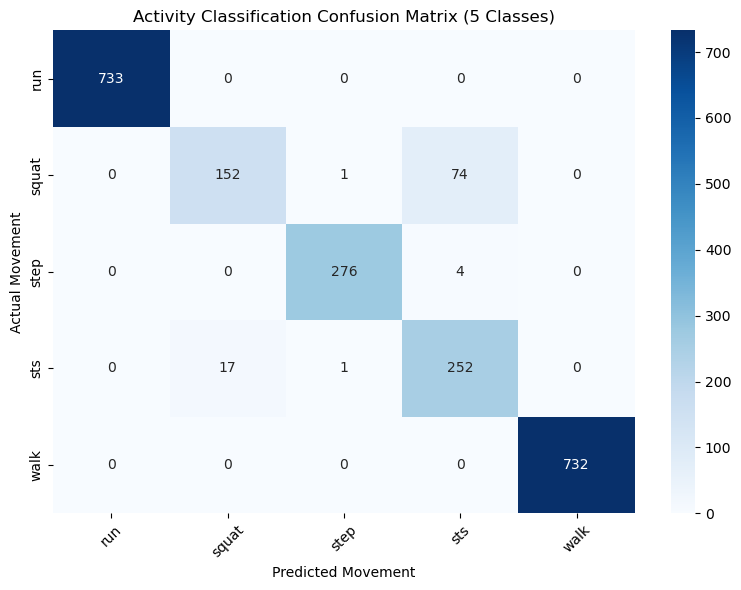

🔀 Mapping labels to C integers: {np.str_('run'): 0, np.str_('squat'): 1, np.str_('step'): 2, np.str_('sts'): 3, np.str_('walk'): 4}

 Generating C header for models: /Users/li0o0sun/projects/Projectwork2026/models/model_lda.h...
 Model export complete!

 Extracting 100 test samples to /Users/li0o0sun/projects/Projectwork2026/models/test_data.h...
 Test data export complete!


In [2]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# ZONE 1: DATA MANAGEMENT
# ==========================================
def load_and_filter_data(filepath, allowed_activities=None):
    """Loads the pickle file, optimizes memory, and filters down to base activities."""
    if not os.path.exists(filepath):
        print(f" File not found: {filepath}")
        return None

    print(f" Loading data from: {filepath} ...")
    df = pd.read_pickle(filepath)

    # Memory optimization
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    # Convert gait phase
    if 'Activity %' in df.columns:
        theta = (df['Activity %'] / 100) * 2 * np.pi
        df['phase_x'] = np.cos(theta)
        df['phase_y'] = np.sin(theta)

    # Filter classes
    if allowed_activities:
        print(f" Pre-filter shape: {df.shape}")
        df = df[df['Activity'].isin(allowed_activities)].copy()
        df.reset_index(drop=True, inplace=True)
        print(f" Post-filter shape (Filtered classes only): {df.shape}")

    return df


# ==========================================
# ZONE 2: MACHINE LEARNING PIPELINE
# ==========================================
class BiosignalPipeline:
    def __init__(self, window_size=200, overlap=100):
        self.window_size = window_size
        self.overlap = overlap
        self.step_size = window_size - overlap
        
        self.scaler = StandardScaler()
        self.lda_model = LinearDiscriminantAnalysis()

    def segment_and_extract(self, df):
        """Slides a window across the dataframe, extracting features per window."""
        print(" Segmenting signals and extracting features...")
        
        emg_cols = [c for c in df.columns if 'EMG_TA_Pool' in c or 'EMG_GM_Pool' in c]
        gonio_cols = [c for c in df.columns if c.startswith('G_')]
        imu_cols = [c for c in df.columns if c.endswith('-f') or c.endswith('-c') or c.endswith('-q') or c.endswith('-h')]
        
        X_features, y_labels = [], []
        
        # Cast to float32 to prevent numpy math errors
        emg_data = df[emg_cols].to_numpy(dtype=np.float32)
        gonio_data = df[gonio_cols].to_numpy(dtype=np.float32)
        imu_data = df[imu_cols].to_numpy(dtype=np.float32)
        labels = df['Activity'].values
        
        for start_idx in range(0, len(df) - self.window_size, self.step_size):
            end_idx = start_idx + self.window_size
            
            # Majority vote label
            window_labels = labels[start_idx:end_idx]
            unique, counts = np.unique(window_labels, return_counts=True)
            majority_label = unique[np.argmax(counts)]
            
            if pd.isna(majority_label):
                continue
                
            y_labels.append(majority_label)
            window_features = []
            
            # EMG Features
            w_emg = emg_data[start_idx:end_idx]
            window_features.extend(np.sqrt(np.mean(w_emg**2, axis=0)))           # RMS
            window_features.extend(np.mean(np.abs(w_emg), axis=0))               # MAV
            window_features.extend(np.sum(np.abs(np.diff(w_emg, axis=0)), axis=0)) # WL
            window_features.extend(np.sum((w_emg[:-1] * w_emg[1:]) < 0, axis=0)) # ZC
            
            # IMU Features
            w_imu = imu_data[start_idx:end_idx]
            window_features.extend(np.mean(w_imu, axis=0))
            window_features.extend(np.std(w_imu, axis=0))
            window_features.extend(np.sqrt(np.mean(w_imu**2, axis=0)))
            window_features.extend(np.sum(w_imu**2, axis=0))
            
            X_features.append(window_features)
            
        return np.nan_to_num(np.array(X_features)), np.array(y_labels)

    def train_model(self, X_train, y_train):
        """Fits the scaler and trains the LDA model."""
        X_train_scaled = self.scaler.fit_transform(X_train)
        self.lda_model.fit(X_train_scaled, y_train)
        return self.lda_model, self.scaler

# ==========================================
# ZONE 2.5: VISUALIZATION & METRICS
# ==========================================
def plot_confusion_matrix(y_true, y_pred, labels):
    """Generates and displays a heatmap of the confusion matrix."""
    print("📈 Generating Confusion Matrix plot...")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    
    plt.title('Activity Classification Confusion Matrix (5 Classes)')
    plt.ylabel('Actual Movement')
    plt.xlabel('Predicted Movement')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# ZONE 3: TINYML EXPORTERS
# ==========================================
def export_model_to_c(scaler, lda, output_file="model_lda.h"):
    """Translates the Python Scaler and LDA model into C arrays."""
    print(f"\n Generating C header for models: {output_file}...")
    n_classes, n_features = lda.coef_.shape

    with open(output_file, 'w') as f:
        f.write("/* Auto-generated LDA Model Parameters */\n")
        f.write("#ifndef MODEL_LDA_H\n#define MODEL_LDA_H\n\n")
        f.write(f"#define NUM_FEATURES {n_features}\n")
        f.write(f"#define NUM_CLASSES {n_classes}\n\n")

        f.write("const float scaler_mean[NUM_FEATURES] = {\n    " + ", ".join([f"{x:.6f}f" for x in scaler.mean_]) + "\n};\n\n")
        f.write("const float scaler_scale[NUM_FEATURES] = {\n    " + ", ".join([f"{x:.6f}f" for x in scaler.scale_]) + "\n};\n\n")
        f.write("const float lda_intercept[NUM_CLASSES] = {\n    " + ", ".join([f"{x:.6f}f" for x in lda.intercept_]) + "\n};\n\n")
        
        f.write("const float lda_coef[NUM_CLASSES][NUM_FEATURES] = {\n")
        for i in range(n_classes):
            f.write("    {" + ", ".join([f"{x:.6f}f" for x in lda.coef_[i]]) + "}" + (",\n" if i < n_classes - 1 else "\n"))
        f.write("};\n\n")

        f.write("const int lda_classes[NUM_CLASSES] = {" + ", ".join([str(i) for i in range(n_classes)]) + "};\n\n")
        f.write("#endif // MODEL_LDA_H\n")
    print(" Model export complete!")

def export_test_data_to_c(X_test, y_test, num_samples=100, output_file="test_data.h"):
    """Exports a subset of features to a C array for Hardware-In-The-Loop testing."""
    print(f"\n Extracting {num_samples} test samples to {output_file}...")
    X_subset = np.array(X_test[:num_samples], dtype=np.float32)
    y_subset = np.array(y_test[:num_samples], dtype=np.int32)
    n_samples, n_features = X_subset.shape

    with open(output_file, 'w') as f:
        f.write("/* Auto-generated Test Dataset */\n")
        f.write("#ifndef TEST_DATA_H\n#define TEST_DATA_H\n\n")
        f.write(f"#define NUM_TEST_SAMPLES {n_samples}\n")
        f.write(f"#define NUM_TEST_FEATURES {n_features}\n\n")

        f.write("const float test_features[NUM_TEST_SAMPLES][NUM_TEST_FEATURES] = {\n")
        for i in range(n_samples):
            f.write("    {" + ", ".join([f"{val:.6f}f" for val in X_subset[i]]) + "}" + (",\n" if i < n_samples - 1 else "\n"))
        f.write("};\n\n")

        f.write("const int test_labels[NUM_TEST_SAMPLES] = {\n    " + ", ".join(map(str, y_subset)) + "\n};\n\n")
        f.write("#endif // TEST_DATA_H\n")
    print(" Test data export complete!")


# ==========================================
# ZONE 4: MAIN EXECUTION CONTROLLER
# ==========================================
if __name__ == "__main__":
    # --- 1. Configuration ---
    BASE_PATH = "/Users/li0o0sun/projects/Projectwork2026/data"
    FILE_NAME = "09_filtered_all_data.pkl"
    MODELS_DIR = "/Users/li0o0sun/projects/Projectwork2026/models"
    ALLOWED_ACTIVITIES = ['run', 'squat', 'step', 'sts', 'walk']
    
    os.makedirs(MODELS_DIR, exist_ok=True)
    
    # --- 2. Load and Filter Data ---
    df = load_and_filter_data(os.path.join(BASE_PATH, FILE_NAME), ALLOWED_ACTIVITIES)
    
    if df is not None:
        # --- 3. Extract Features ---
        pipeline = BiosignalPipeline(window_size=200, overlap=100)
        X_unscaled, y_text = pipeline.segment_and_extract(df)
        
        # --- 4. Chronological Train/Test Split (80/20) ---
        print(" Splitting data chronologically per class(80/20)...")
        X_train_list, X_test_list, y_train_list, y_test_list = [], [], [], []
        unique_classes = np.unique(y_text)
        
        for cls in unique_classes:
            cls_indices = np.where(y_text == cls)[0]
            split_point = int(len(cls_indices) * 0.8)
            
            X_train_list.extend(X_unscaled[cls_indices[:split_point]])
            y_train_list.extend(y_text[cls_indices[:split_point]])
            X_test_list.extend(X_unscaled[cls_indices[split_point:]])
            y_test_list.extend(y_text[cls_indices[split_point:]])
            
        X_train = np.array(X_train_list)
        X_test = np.array(X_test_list)
        y_train = np.array(y_train_list)
        y_test_text = np.array(y_test_list)
        
        # --- 5. Train Model & Evaluate ---
        print(" Training LDA Model...")
        trained_model, fitted_scaler = pipeline.train_model(X_train, y_train)
        
        print("\n Evaluating Model on Test Data...")
        X_test_scaled = fitted_scaler.transform(X_test)
        y_pred = trained_model.predict(X_test_scaled)
        print(classification_report(y_test_text, y_pred))

        # Plot the Confusion Matrix
        class_labels = sorted(list(set(y_test_text)))
        plot_confusion_matrix(y_test_text, y_pred, class_labels)
        
        # --- 6. Export to C (Models & Test Data) ---
        class_mapping = {label: idx for idx, label in enumerate(trained_model.classes_)}
        print(f" Mapping labels to C integers: {class_mapping}")
        
        y_test_encoded = np.array([class_mapping[label] for label in y_test_text], dtype=np.int32)
        
        # Shuffle test set for balanced embedded testing
        shuffle_idx = np.random.permutation(len(y_test_encoded))
        X_test_shuffled = X_test[shuffle_idx]
        y_test_encoded_shuffled = y_test_encoded[shuffle_idx]
        
        export_model_to_c(fitted_scaler, trained_model, os.path.join(MODELS_DIR, "model_lda.h"))
        export_test_data_to_c(X_test_shuffled, y_test_encoded_shuffled, num_samples=100, output_file=os.path.join(MODELS_DIR, "test_data.h"))